## 1. 环境准备

导入必要的库并配置中文字体支持。

In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 数据集介绍与加载

为了更好地理解随机森林算法的实际应用，我们选择经典的**鸢尾花**（Iris）数据集作为示例。该数据集包含 **150** 个样本，分为 3 个类别（`Setosa`、`Versicolor`、`Virginica`），每个类别有 50 个样本。每个样本具有 4 个特征：花萼长度（`sepal length`）、花萼宽度（`sepal width`）、花瓣长度（`petal length`）和花瓣宽度（`petal width`），均为数值型数据，单位为厘米。

首先，我们需要加载数据集并进行一些基本的探索性数据分析，以便了解数据的分布和特征之间的关系。

In [2]:
# 加载鸢尾花数据集
iris = load_iris()
X = iris.data  # 特征数据
y = iris.target  # 标签数据
feature_names = iris.feature_names
target_names = iris.target_names

# 打印数据集的基本信息
print("数据集描述：")
print(iris.DESCR)

# 打印前5个样本
print("\n前5个样本：")
print(pd.DataFrame(X[:5], columns=feature_names))

# 打印每个类别的样本数量
print("\n每个类别的样本数量：")
print(pd.Series(y).value_counts())

数据集描述：
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 class

## 3. 数据预处理

对数据进行预处理，包括划分训练集和测试集、特征标准化等操作。

In [3]:
# 划分训练集和测试集，测试集占20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特征标准化，使每个特征的均值为0，标准差为1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. 随机森林模型的训练与评估

在完成数据预处理后，我们使用 Python 的 scikit-learn 库来构建随机森林分类器，并对模型进行训练和评估。为了验证模型的泛化能力，我们还可以开启 `oob_score` 来计算袋外分数。

In [4]:
# 创建随机森林分类器，设置估计器数量为100，并开启oob_score
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)

# 训练模型
rf_classifier.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = rf_classifier.predict(X_test)

# 计算模型的准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"\n模型准确率：{accuracy:.4f}")

# 输出 OOB Score
print(f"OOB Score: {rf_classifier.oob_score_:.4f}")

# 输出分类报告，包括精确度、召回率、F1分数等指标
print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=target_names))

# 输出混淆矩阵，直观展示分类结果
print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred))


模型准确率：1.0000
OOB Score: 0.9167

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


混淆矩阵：
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## 5. 特征重要性评估

随机森林的一个重要特性是能够评估特征的重要性。通过分析特征重要性，我们可以了解哪些特征对模型的预测结果贡献最大。

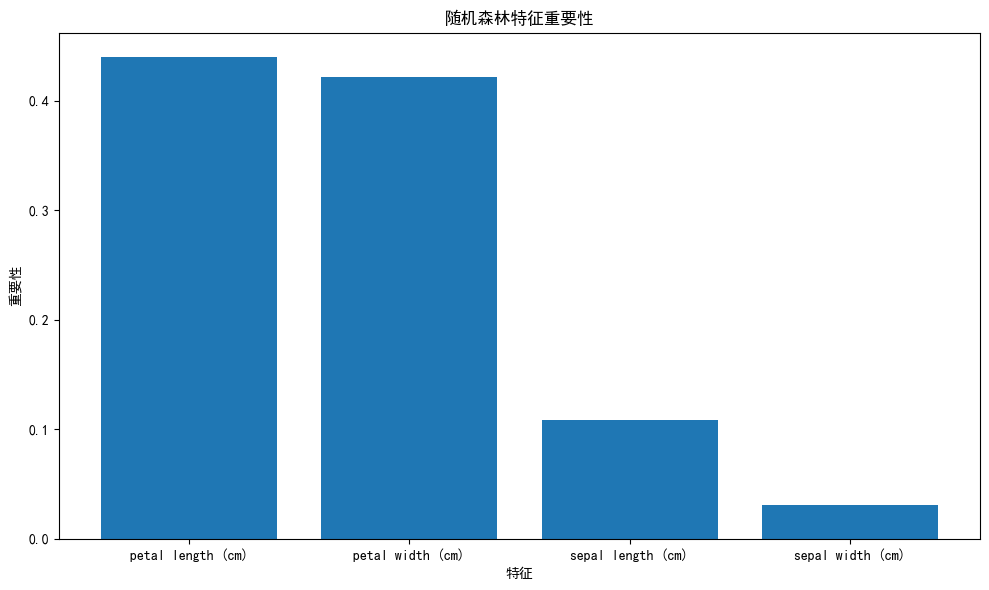

In [5]:
# 特征重要性可视化
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("随机森林特征重要性")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices])
plt.xlabel("特征")
plt.ylabel("重要性")
plt.tight_layout()
plt.show()

## 6. 模型优化与调参

为了进一步提高模型的性能，我们可以对随机森林的超参数进行优化。常见的超参数包括估计器数量（n_estimators）、最大深度（max_depth）、最小分裂样本数（min_samples_split）等。通过使用网格搜索（Grid Search）或随机搜索（Random Search）等方法，我们可以找到最优的参数组合。

In [6]:
# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# 创建网格搜索对象，使用5折交叉验证
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1)

# 在训练集上进行网格搜索
grid_search.fit(X_train, y_train)

# 输出最优参数组合和对应的最佳得分
print(f"\n最优参数组合：{grid_search.best_params_}")
print(f"最佳交叉验证得分：{grid_search.best_score_:.4f}")

# 使用最优参数重新训练模型
best_rf = grid_search.best_estimator_
# best_rf.fit(X_train, y_train) # GridSearchCV 默认 refit=True

# 在测试集上评估最优模型
y_pred_best = best_rf.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"\n最优模型在测试集上的准确率：{accuracy_best:.4f}")


最优参数组合：{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
最佳交叉验证得分：0.9583

最优模型在测试集上的准确率：1.0000


## 7. 模型应用与案例分析

通过上述步骤，我们已经训练并优化了一个随机森林分类器，可以将其应用于实际的鸢尾花分类任务中。例如，我们可以输入一个新的样本数据，预测其所属的类别。

In [7]:
# 假设有一个新的样本，其特征为：花萼长度=5.1，花萼宽度=3.5，花瓣长度=1.4，花瓣宽度=0.2
new_sample = [[5.1, 3.5, 1.4, 0.2]]

# 对新样本进行特征标准化
new_sample_scaled = scaler.transform(new_sample)

# 使用最优模型进行预测
predicted_class = best_rf.predict(new_sample_scaled)
predicted_class_name = target_names[predicted_class][0]

print(f"\n新样本的预测类别：{predicted_class_name}")


新样本的预测类别：setosa
